In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import math

In [2]:
my_seed = 1780065908
rng = np.random.default_rng(seed=my_seed)
my_seed

1780065908

# KMeans algorithm

In [3]:
def _validate_inputs(k, X):
    if X is None or X.size == 0:
        raise ValueError("Error: Dataset X is empty.")
    if k <= 0:
        raise ValueError(f"Error: k must be greater than 0. Received k={k}.")
    if k > X.shape[0]:
        raise ValueError(f"Error: k ({k}) cannot be greater than the number of data points in the dataset ({X.shape[0]}).")
    if np.isnan(X).any() or np.isinf(X).any():
        raise ValueError("Error: Dataset X contains NaN (Not a Number) or Infinite values.")

In [4]:
def _inner_kmeans(k, X, centroids):
    while True:
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])
        if np.allclose(centroids, new_centroids): break
        centroids = new_centroids
    return centroids, distances, labels

In [5]:
def kmeans(k, X):
    _validate_inputs(k, X)
    return _inner_kmeans(k, X, 
        X[rng.choice(X.shape[0], size=k, replace=False)]
    )

# KMeans++ algorithm

In [6]:
def kmeans_plus_plus(k, X):
    _validate_inputs(k, X)
    centroids = [X[rng.choice(X.shape[0])]]
    D2 = np.inf 
    for _ in range(1, k):
        D2 = np.minimum(D2, np.sum((X - centroids[-1])**2, axis=1))
        sum_D2 = np.sum(D2)
        probs = D2 / sum_D2 if sum_D2 > 0 else np.ones(X.shape[0]) / X.shape[0]
        centroids.append(X[rng.choice(X.shape[0], p=probs)])
    return _inner_kmeans(k, X, np.array(centroids))

# Utility functions

In [7]:
def run_trials(algo, k, X, trials):
    times, inertias, bincounts = [], [], []
    for trial in range(trials):
        start = time.perf_counter()
        _, distances, labels = algo(k, X)
        end = time.perf_counter()
        times.append(end - start)
        inertias.append(np.sum(np.min(distances**2, axis=1)))
        bincounts.append(np.bincount(labels, minlength=k))
    return {'inertias': inertias, 'times': times, 'bincounts': bincounts}

In [8]:
def show_distributions(bincounts, filename):
    trials = len(bincounts)
    rows = math.floor(math.sqrt(trials))
    cols = math.ceil(trials / rows)
    _, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    for i in range(trials): show_bar_diagram(bincounts[i], axes[i], f"Trial {i + 1}")
    plt.tight_layout()
    plt.savefig(f'img/{filename}.jpg', dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
def show_bar_diagram(count, ax, title):
    ax.bar(range(len(count)), count, color='royalblue', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster ID', fontsize=10)
    ax.set_ylabel('Number of datapoints', fontsize=10)
    ax.set_xticks(range(len(count)))
    ax.set_xticklabels(range(len(count)), rotation=90, fontsize=5)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

In [10]:
def show_boxplot(ax, k, is_first, stats):
    box = ax.boxplot(
        [stats[k]['kmeans']['inertias'], stats[k]['kmeanspp']['inertias']], 
        tick_labels=['KMeans', 'KMeans++'],
        patch_artist=True,
        widths=0.5
    )
    for patch, color in zip(box['boxes'], ['#aec7e8', '#98df8a']):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
    for median in box['medians']: median.set(color='black', linewidth=1.5)
    ax.set_title(f'k = {k}', fontsize=14, fontweight='bold')
    if is_first: ax.set_ylabel('Inertia', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

In [11]:
def show_stability_graphs(stats, filename):
    number_of_k_values = len(stats.keys())
    rows = math.floor(math.sqrt(number_of_k_values))
    cols = math.ceil(number_of_k_values / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6), sharey=False)
    for i, k in enumerate(stats.keys()): show_boxplot(axes[i], k, i == 0, stats)
    fig.suptitle('Stability comparison: KMeans vs KMeans++', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'img/{filename}.jpg', dpi=300, bbox_inches="tight")
    plt.show()

# Synthetic dataset

### Generation

To evaluate the algorithms in a controlled environment, we generated a synthetic dataset following the methodology described in Section 6.1 ("Datasets") of the foundational paper *"k-means++: The Advantages of Careful Seeding"* (Arthur & Vassilvitskii, SODA 2007). 

The dataset properties are configured as follows:
* **Dimensions:** $d = 20$
* **Centers:** $k = 27$, chosen uniformly at random from a 20-dimensional hypercube of side length $700$ centered at the origin.
* **Distribution:** For each center, $50$ data points were sampled from a multivariate Gaussian distribution with unit variance ($\sigma^2 = 1$).
* **Total Dataset Size:** $N = 1350$ data points ($27 \times 50$). 

> **Note:** The generating centers serve exclusively as the ground-truth distribution parameters and are not included as queryable points within the final dataset.

In [12]:
hypercube_center = 0 # in all dimensions
hypercube_side = 700
k = 27
d = 20
variance = 1
datapoints_per_center = 50

In [13]:
centers = rng.uniform(hypercube_center - hypercube_side/2, hypercube_center + hypercube_side/2, (k, d))
X = np.vstack([rng.normal(loc=c, scale=math.sqrt(variance), size=(datapoints_per_center, d)) for c in centers])
X

array([[ 198.52334007,  -59.32986218, -216.11959669, ..., -304.86312726,
         -90.84238821, -179.24290236],
       [ 199.25747939,  -56.76055758, -217.26079519, ..., -304.76561227,
         -91.26439569, -181.40939978],
       [ 196.55410149,  -55.34307934, -218.05016846, ..., -302.6148682 ,
         -90.82054674, -179.1376287 ],
       ...,
       [ 148.93488423,  -80.19887782,  -35.50606835, ...,  210.84562114,
        -342.43806796, -283.70346077],
       [ 150.18967991,  -81.14742087,  -34.44079625, ...,  209.27425302,
        -342.60148391, -284.76003486],
       [ 149.16481847,  -80.61723792,  -36.63464216, ...,  210.63222422,
        -344.74189875, -285.09120657]], shape=(1350, 20))

In [14]:
centers.shape, X.shape

((27, 20), (1350, 20))

### Initialization

In [15]:
trials = 20

In [16]:
syn_k_values = [10, 27, 50]

In [17]:
syn_stats = {}
for k in syn_k_values: syn_stats[k] = {}

### KMeans executions

In [18]:
for k in syn_k_values:
    syn_stats[k]['kmeans'] = run_trials(kmeans, k, X, trials)

#### Stats

In [19]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(syn_stats[k]['kmeans']['times']):.4f} s")
    print(f"Average inertia: {np.mean(syn_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(syn_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(syn_stats[k]['kmeans']['inertias']):.4e}")
    if i < len(syn_k_values) - 1: print()

k = 10
--------------------
Average execution time: 0.0064 s
Average inertia: 5.8349e+08
Inertia standard deviation: 2.7897e+07
Minimum inertia: 5.3707e+08

k = 27
--------------------
Average execution time: 0.0227 s
Average inertia: 1.9561e+08
Inertia standard deviation: 5.3177e+07
Minimum inertia: 1.1532e+08

k = 50
--------------------
Average execution time: 0.0506 s
Average inertia: 3.5077e+07
Inertia standard deviation: 2.7833e+07
Minimum inertia: 2.5281e+04


#### Cluster sizes distributions

k = 10
--------------------


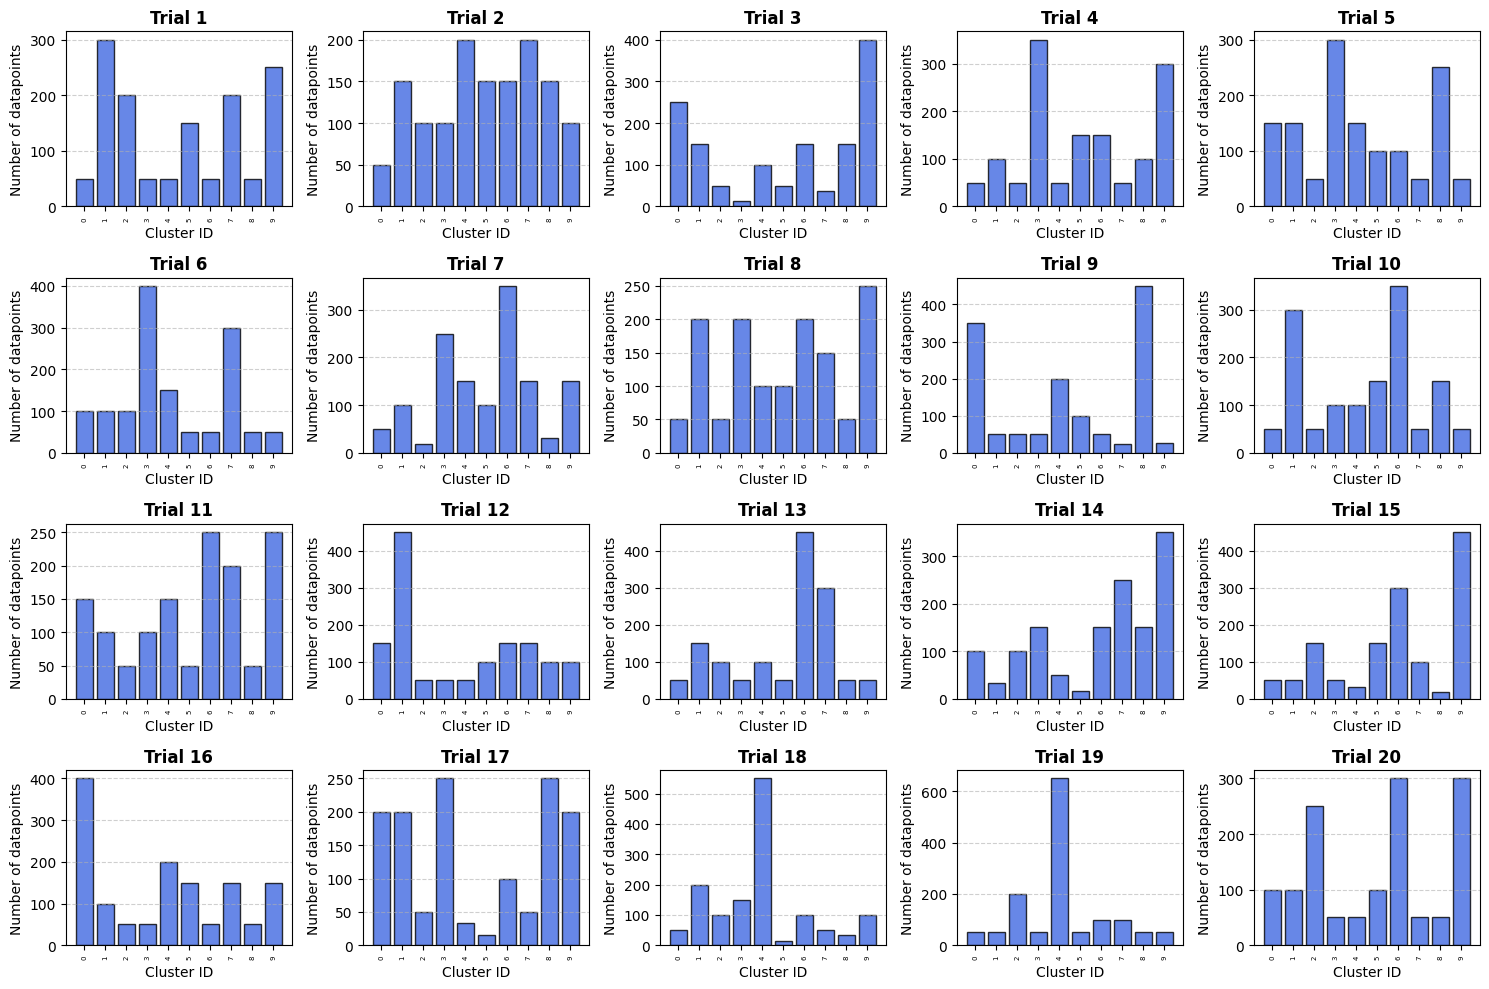


k = 27
--------------------


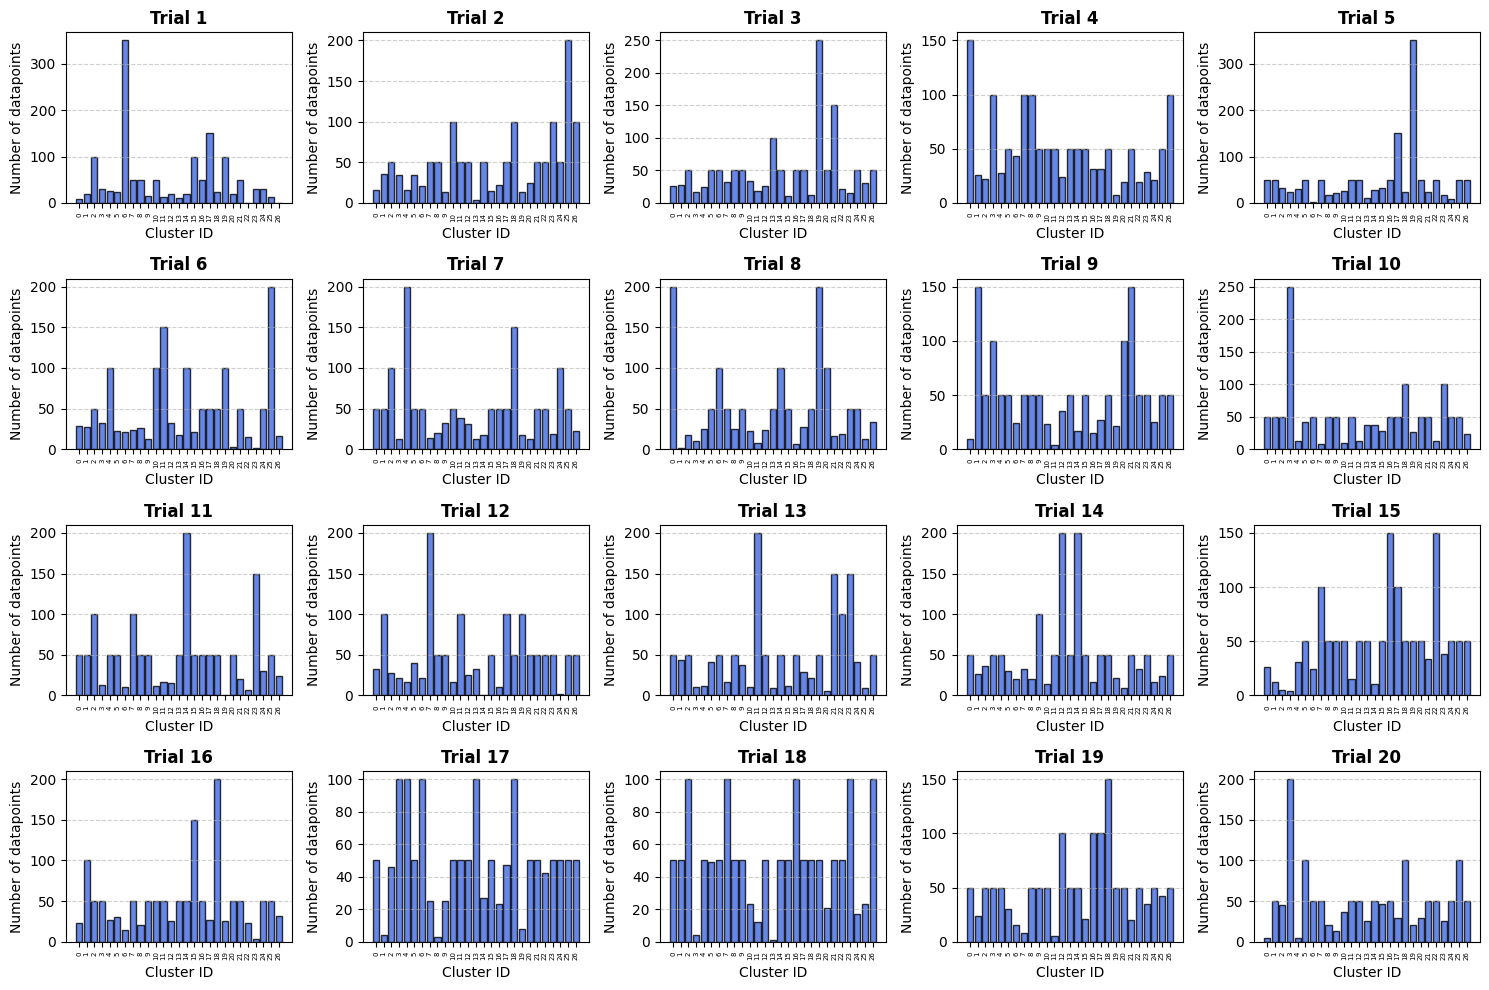


k = 50
--------------------


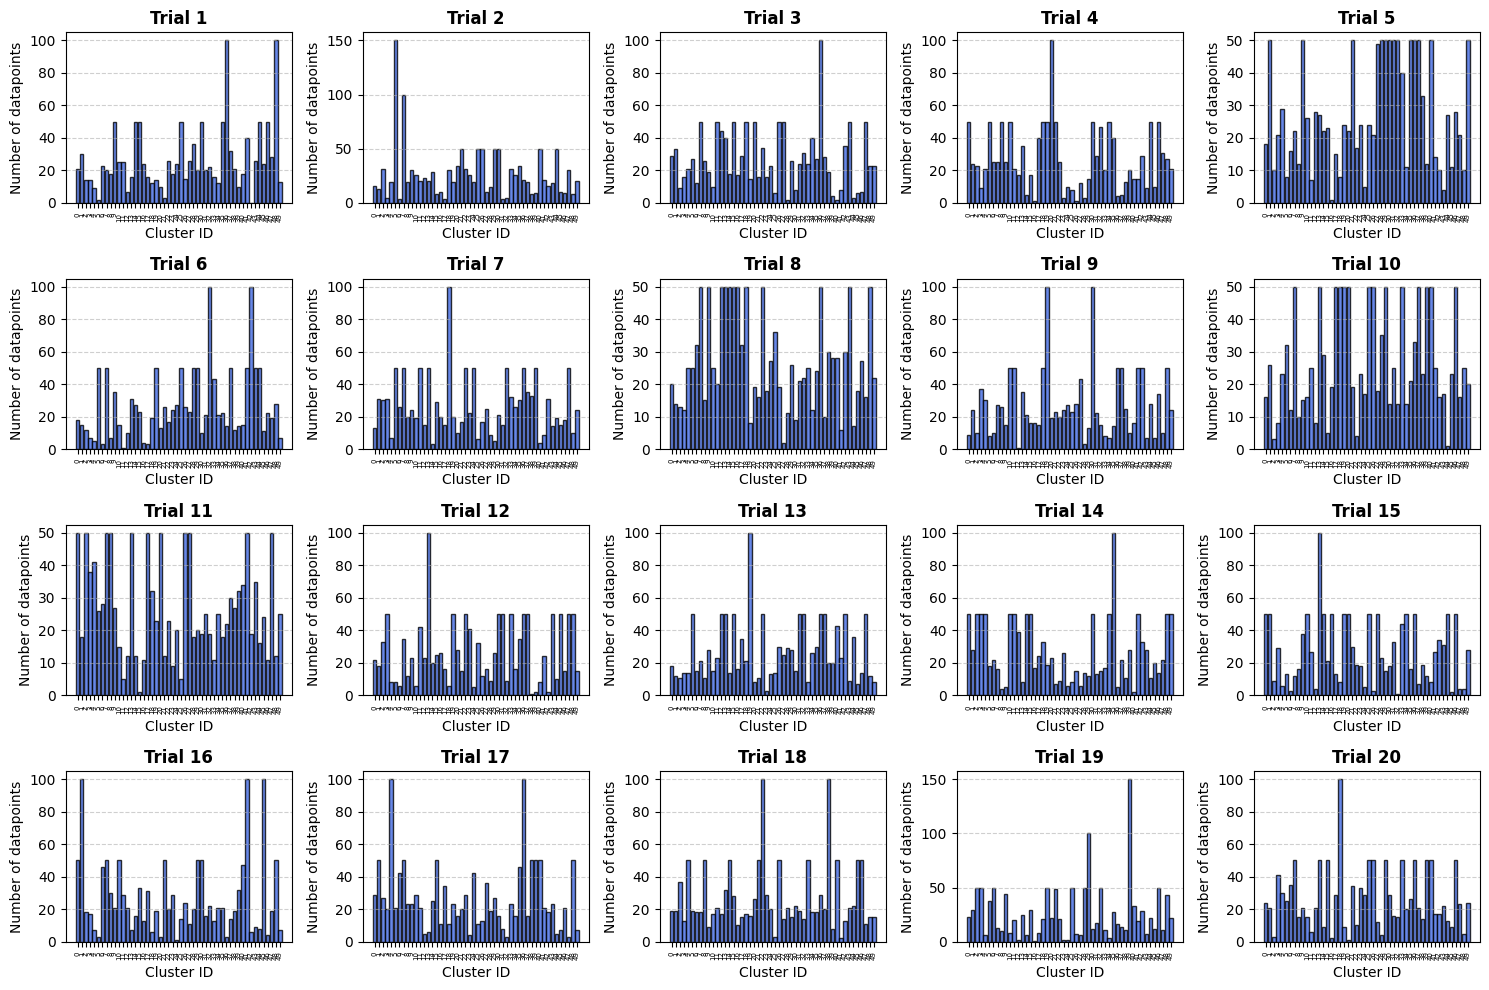

In [20]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(syn_stats[k]['kmeans']['bincounts'], f'cl_sz_distr_syn_km_k{k}')
    if i < len(syn_k_values) - 1: print()

### KMeans++ executions

In [21]:
for k in syn_k_values:
    syn_stats[k]['kmeanspp'] = run_trials(kmeans_plus_plus, k, X, trials)

#### Stats

In [22]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(syn_stats[k]['kmeanspp']['times']):.4f} s")
    print(f"Average inertia: {np.mean(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(syn_stats[k]['kmeanspp']['inertias']):.4e}")
    if i < len(syn_k_values) - 1: print()

k = 10
--------------------
Average execution time: 0.0060 s
Average inertia: 5.4443e+08
Inertia standard deviation: 1.8343e+07
Minimum inertia: 4.9334e+08

k = 27
--------------------
Average execution time: 0.0101 s
Average inertia: 2.6833e+04
Inertia standard deviation: 0.0000e+00
Minimum inertia: 2.6833e+04

k = 50
--------------------
Average execution time: 0.0667 s
Average inertia: 2.5294e+04
Inertia standard deviation: 5.9247e+01
Minimum inertia: 2.5175e+04


#### Cluster sizes distributions

k = 10
--------------------


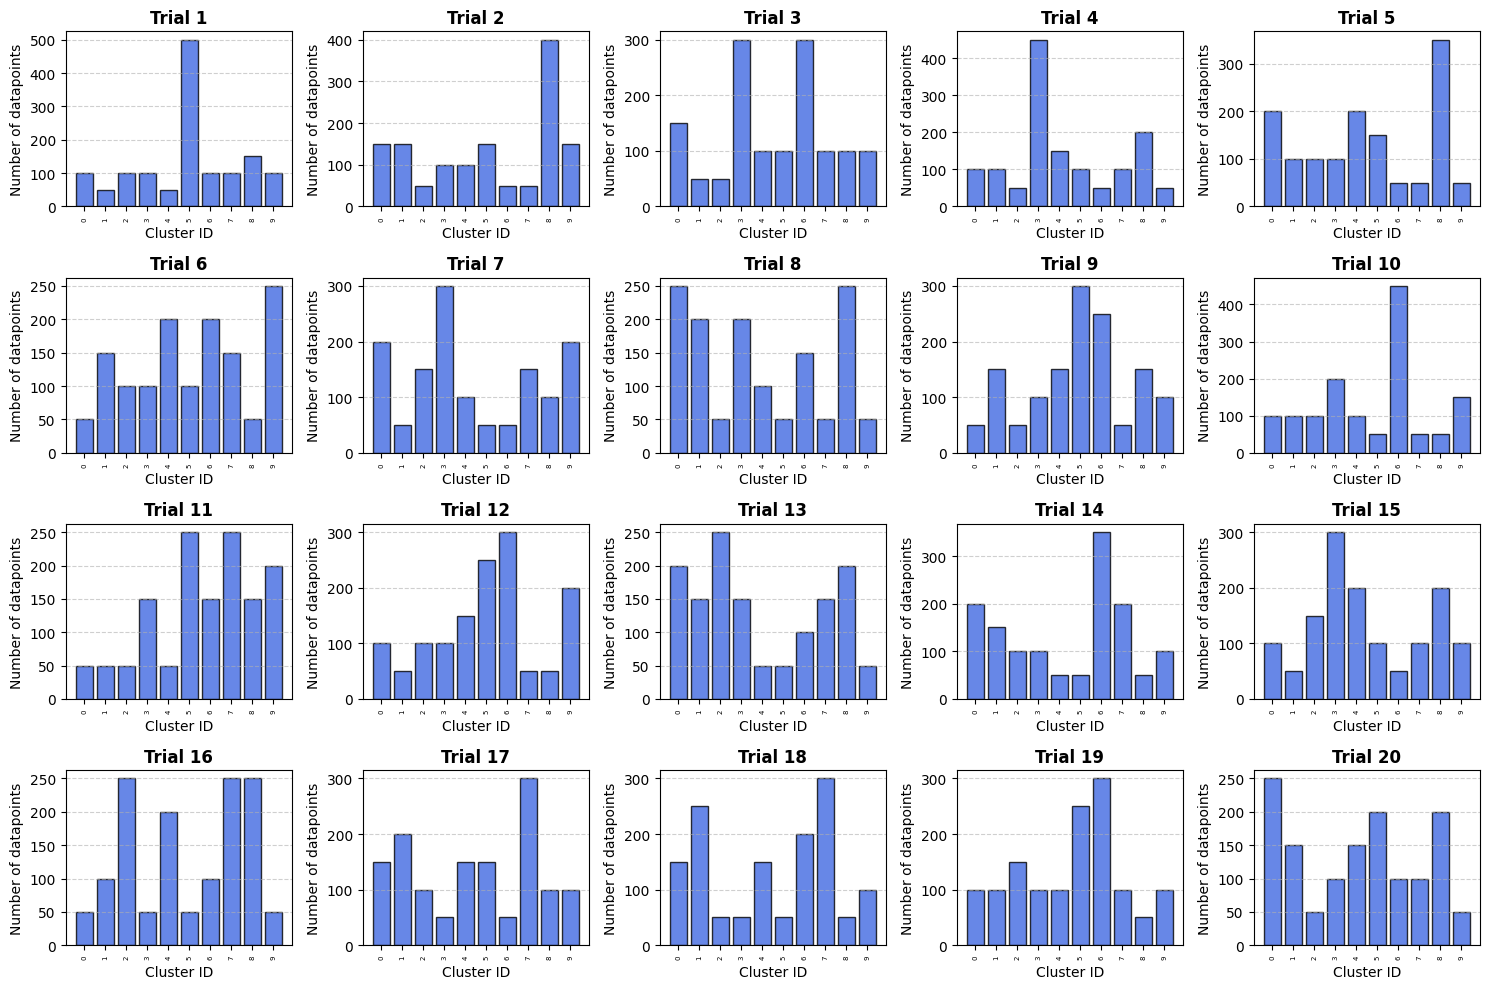


k = 27
--------------------


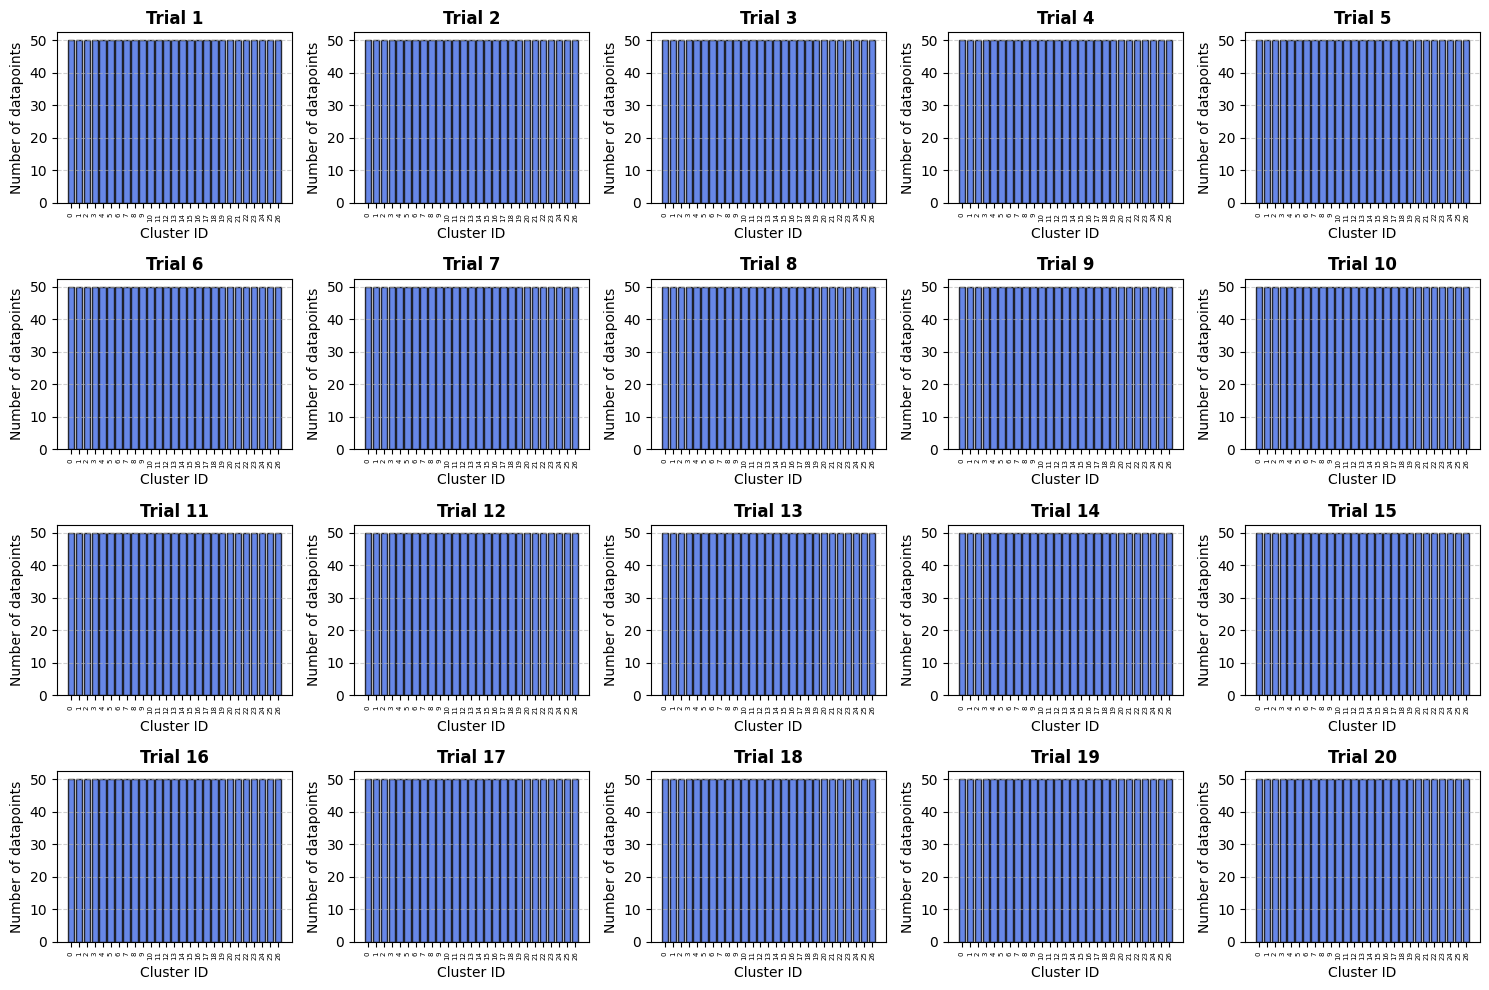


k = 50
--------------------


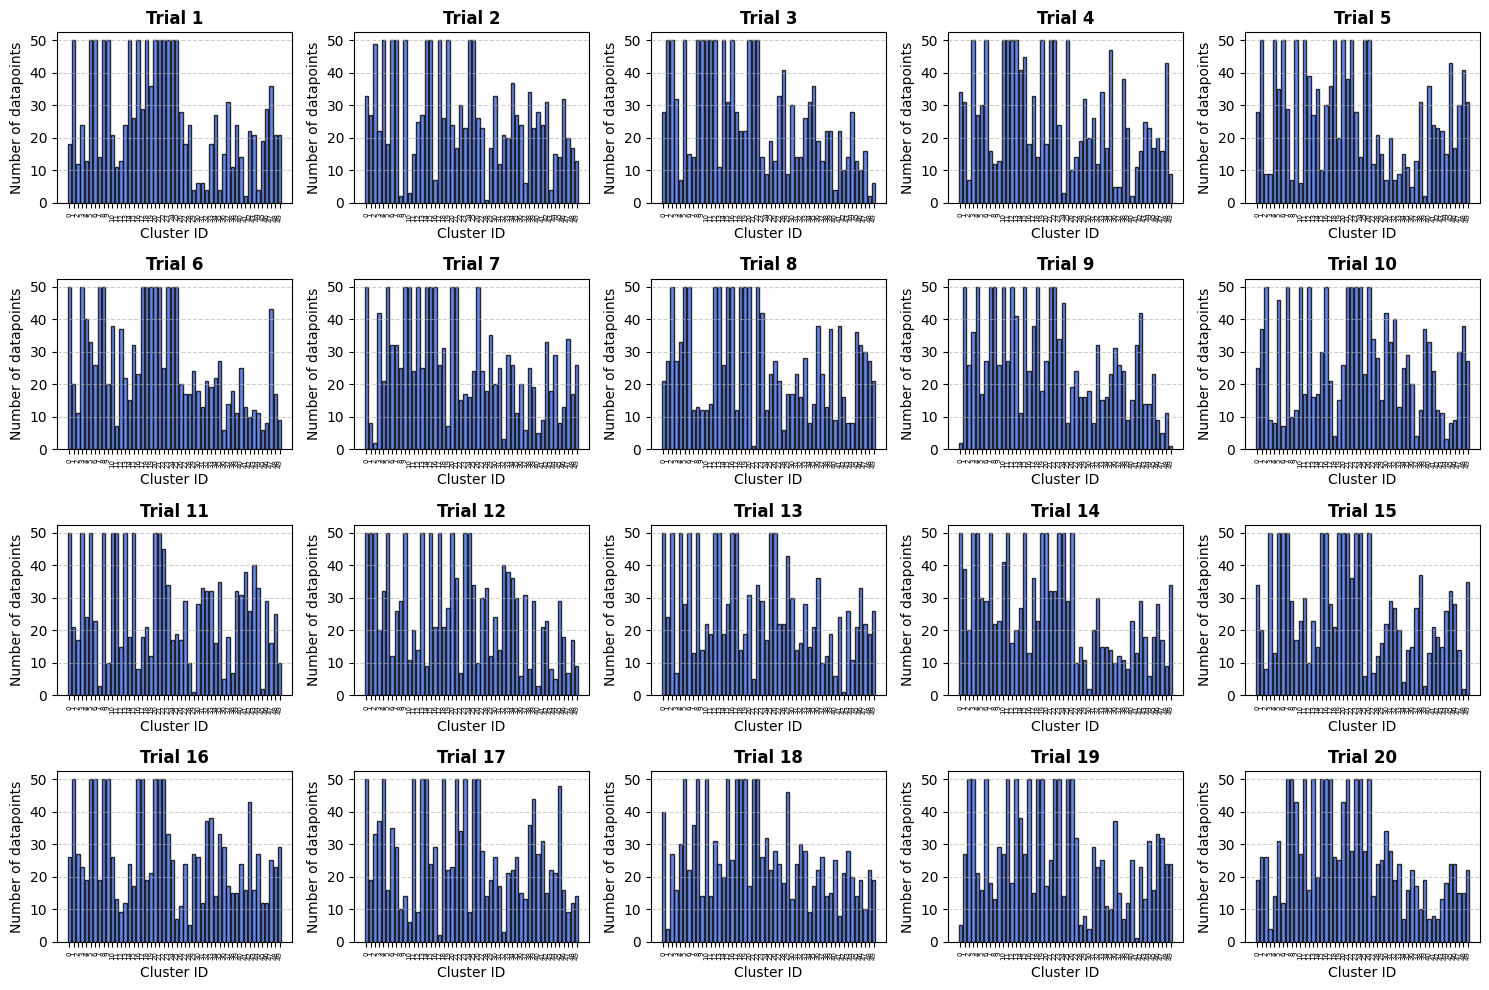

In [23]:
for i, k in enumerate(syn_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(syn_stats[k]['kmeanspp']['bincounts'], f'cl_sz_distr_syn_kmpp_k{k}')
    if i < len(syn_k_values) - 1: print()

### Improvement analysis

In [24]:
for i, (k, v) in enumerate(syn_stats.items()):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time improvement: {100*(1-np.mean(syn_stats[k]['kmeanspp']['times']) / np.mean(syn_stats[k]['kmeans']['times']))}%")
    print(f"Average inertia improvement: {100*(1-np.mean(syn_stats[k]['kmeanspp']['inertias']) / np.mean(syn_stats[k]['kmeans']['inertias']))}%")
    print(f"Inertia standard deviation improvement: {100*(1-np.std(syn_stats[k]['kmeanspp']['inertias']) / np.std(syn_stats[k]['kmeans']['inertias']))}%")
    print(f"Minimum inertia improvement: {100*(1-np.min(syn_stats[k]['kmeanspp']['inertias']) / np.min(syn_stats[k]['kmeans']['inertias']))}%")
    if i < len(syn_stats.items()) - 1: print()

k = 10
--------------------
Average execution time improvement: 6.741262577873719%
Average inertia improvement: 6.694171118386705%
Inertia standard deviation improvement: 34.247549776515584%
Minimum inertia improvement: 8.14158539840032%

k = 27
--------------------
Average execution time improvement: 55.61515159996211%
Average inertia improvement: 99.98628234839532%
Inertia standard deviation improvement: 100.0%
Minimum inertia improvement: 99.97673102827686%

k = 50
--------------------
Average execution time improvement: -31.848334522381027%
Average inertia improvement: 99.92788988477916%
Inertia standard deviation improvement: 99.99978713436755%
Minimum inertia improvement: 0.4165952761806424%


### Stability analysis

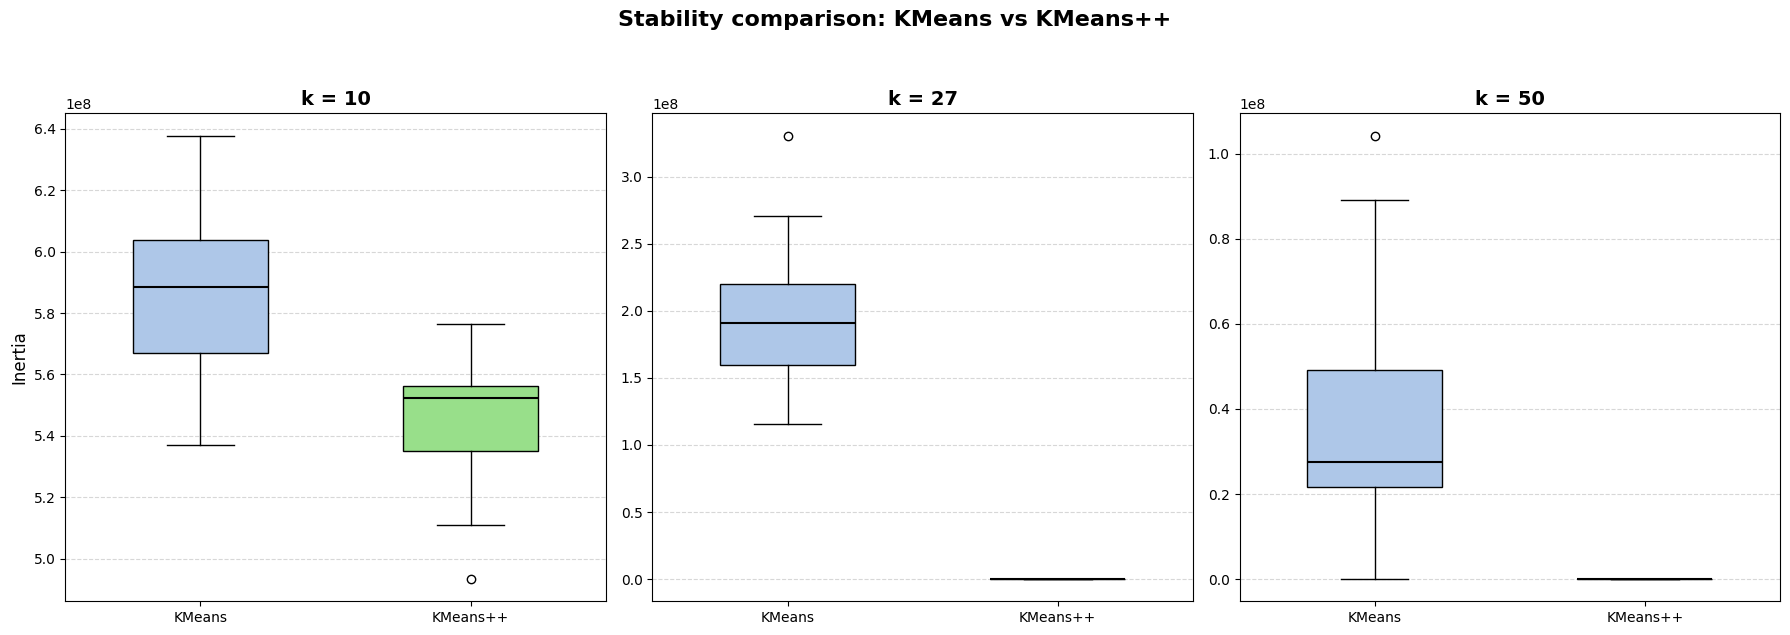

In [25]:
show_stability_graphs(syn_stats, 'stab_syn')

# Real dataset

### Parsing

In [26]:
data_real = np.loadtxt('isolet/isolet.data', delimiter=',')
X_real = data_real[:, :-1]
X_real

array([[-0.4394, -0.093 ,  0.1718, ...,  0.641 ,  0.5898, -0.4872],
       [-0.4348, -0.1198,  0.2474, ...,  0.4318,  0.4546, -0.091 ],
       [-0.233 ,  0.2124,  0.5014, ...,  0.254 ,  0.1588, -0.4762],
       ...,
       [-0.6696, -0.373 ,  0.1584, ...,  0.0728,  0.0728, -0.5818],
       [-0.5764, -0.1764,  0.5106, ...,  0.3044, -0.0434, -0.5   ],
       [-0.6624, -0.3334,  0.3666, ..., -0.0894, -0.1708, -0.317 ]],
      shape=(7797, 617))

### Initialization

In [27]:
real_k_values = [10, 26, 50]

In [28]:
real_stats = {}
for k in real_k_values: real_stats[k] = {}

### KMeans executions

In [29]:
for k in real_k_values:
    real_stats[k]['kmeans'] = run_trials(kmeans, k, X_real, trials)

#### Stats

In [30]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(real_stats[k]['kmeans']['times']):.4f} s")
    print(f"Average inertia: {np.mean(real_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(real_stats[k]['kmeans']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(real_stats[k]['kmeans']['inertias']):.4e}")
    if i < len(real_k_values) - 1: print()

k = 10
--------------------
Average execution time: 4.7443 s
Average inertia: 5.3747e+05
Inertia standard deviation: 5.6979e+03
Minimum inertia: 5.2857e+05

k = 26
--------------------
Average execution time: 12.2178 s
Average inertia: 4.4737e+05
Inertia standard deviation: 4.7067e+03
Minimum inertia: 4.4025e+05

k = 50
--------------------
Average execution time: 24.2417 s
Average inertia: 4.0531e+05
Inertia standard deviation: 1.2575e+03
Minimum inertia: 4.0350e+05


#### Cluster sizes distributions

k = 10
--------------------


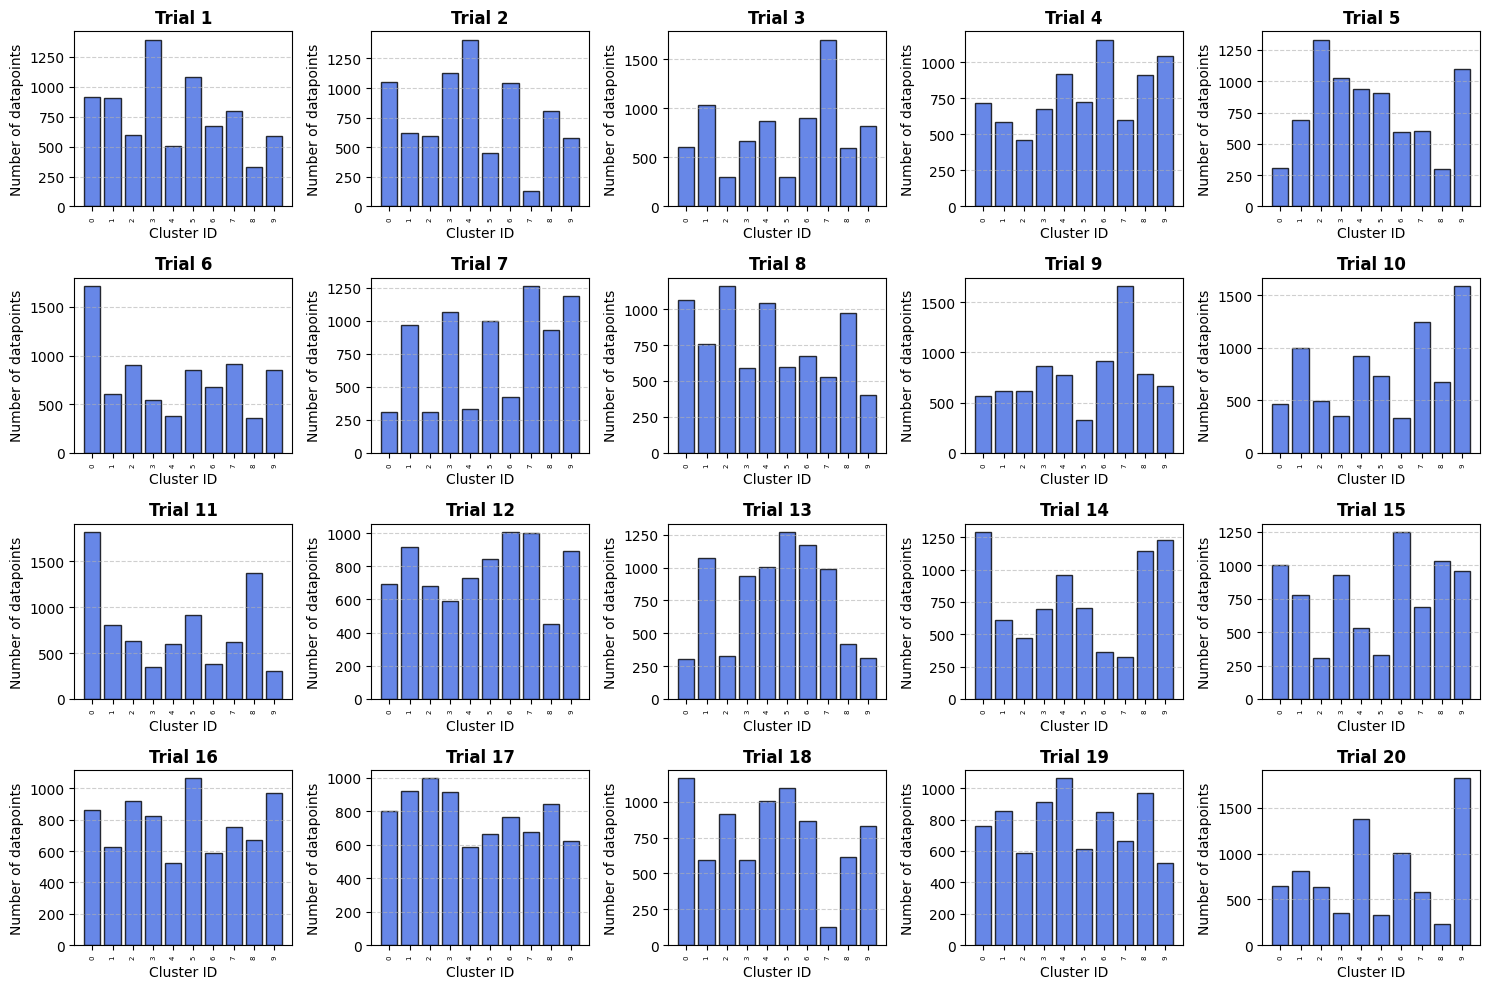


k = 26
--------------------


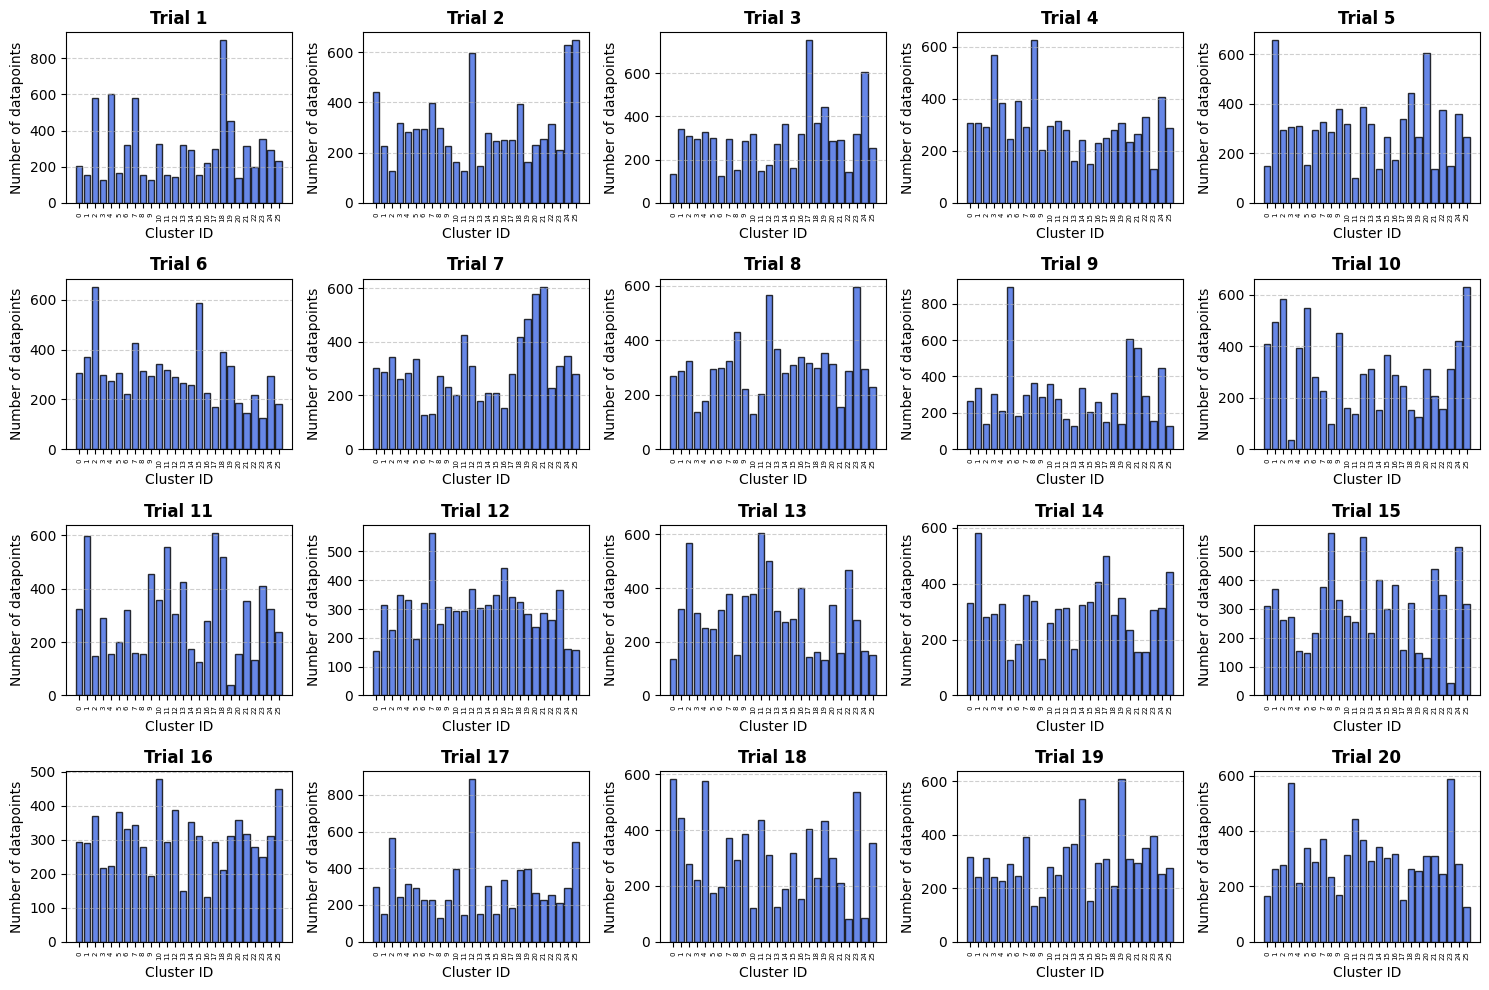


k = 50
--------------------


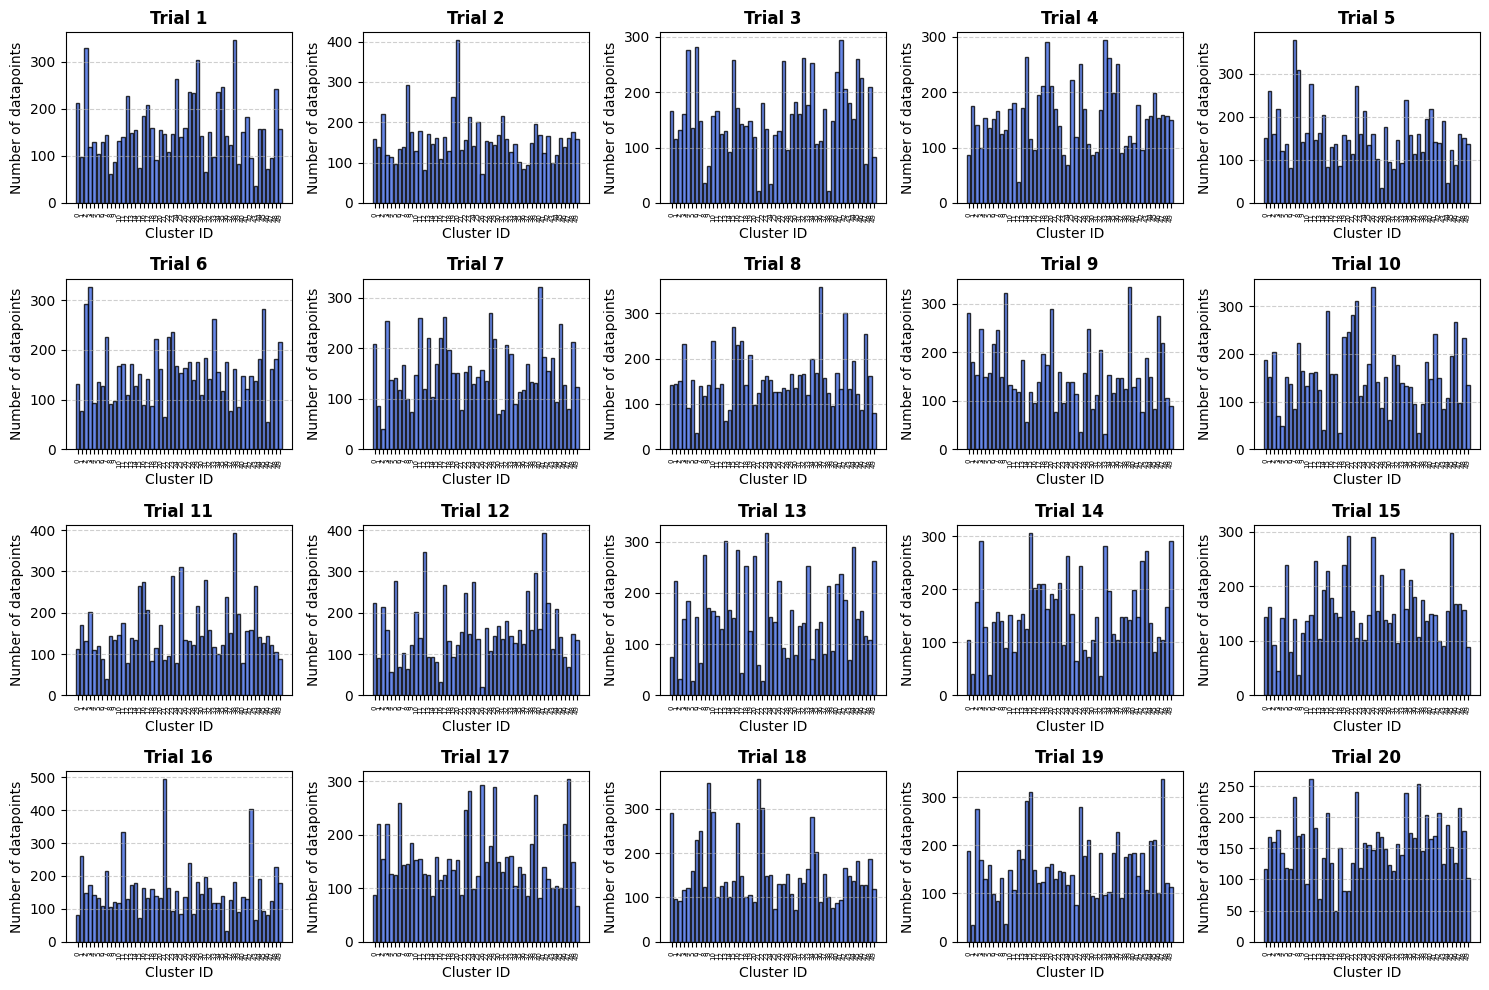

In [31]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(real_stats[k]['kmeans']['bincounts'], f'cl_sz_distr_real_km_k{k}')
    if i < len(real_k_values) - 1: print()

### KMeans++ executions

In [32]:
for k in real_k_values:
    real_stats[k]['kmeanspp'] = run_trials(kmeans_plus_plus, k, X_real, trials)

#### Stats

In [33]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time: {np.mean(real_stats[k]['kmeanspp']['times']):.4f} s")
    print(f"Average inertia: {np.mean(real_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Inertia standard deviation: {np.std(real_stats[k]['kmeanspp']['inertias']):.4e}")
    print(f"Minimum inertia: {np.min(real_stats[k]['kmeanspp']['inertias']):.4e}")
    if i < len(real_k_values) - 1: print()

k = 10
--------------------
Average execution time: 4.3281 s
Average inertia: 5.3467e+05
Inertia standard deviation: 3.2580e+03
Minimum inertia: 5.2998e+05

k = 26
--------------------
Average execution time: 11.1695 s
Average inertia: 4.4552e+05
Inertia standard deviation: 3.2310e+03
Minimum inertia: 4.4015e+05

k = 50
--------------------
Average execution time: 26.7633 s
Average inertia: 4.0493e+05
Inertia standard deviation: 1.1948e+03
Minimum inertia: 4.0285e+05


#### Cluster sizes distributions

k = 10
--------------------


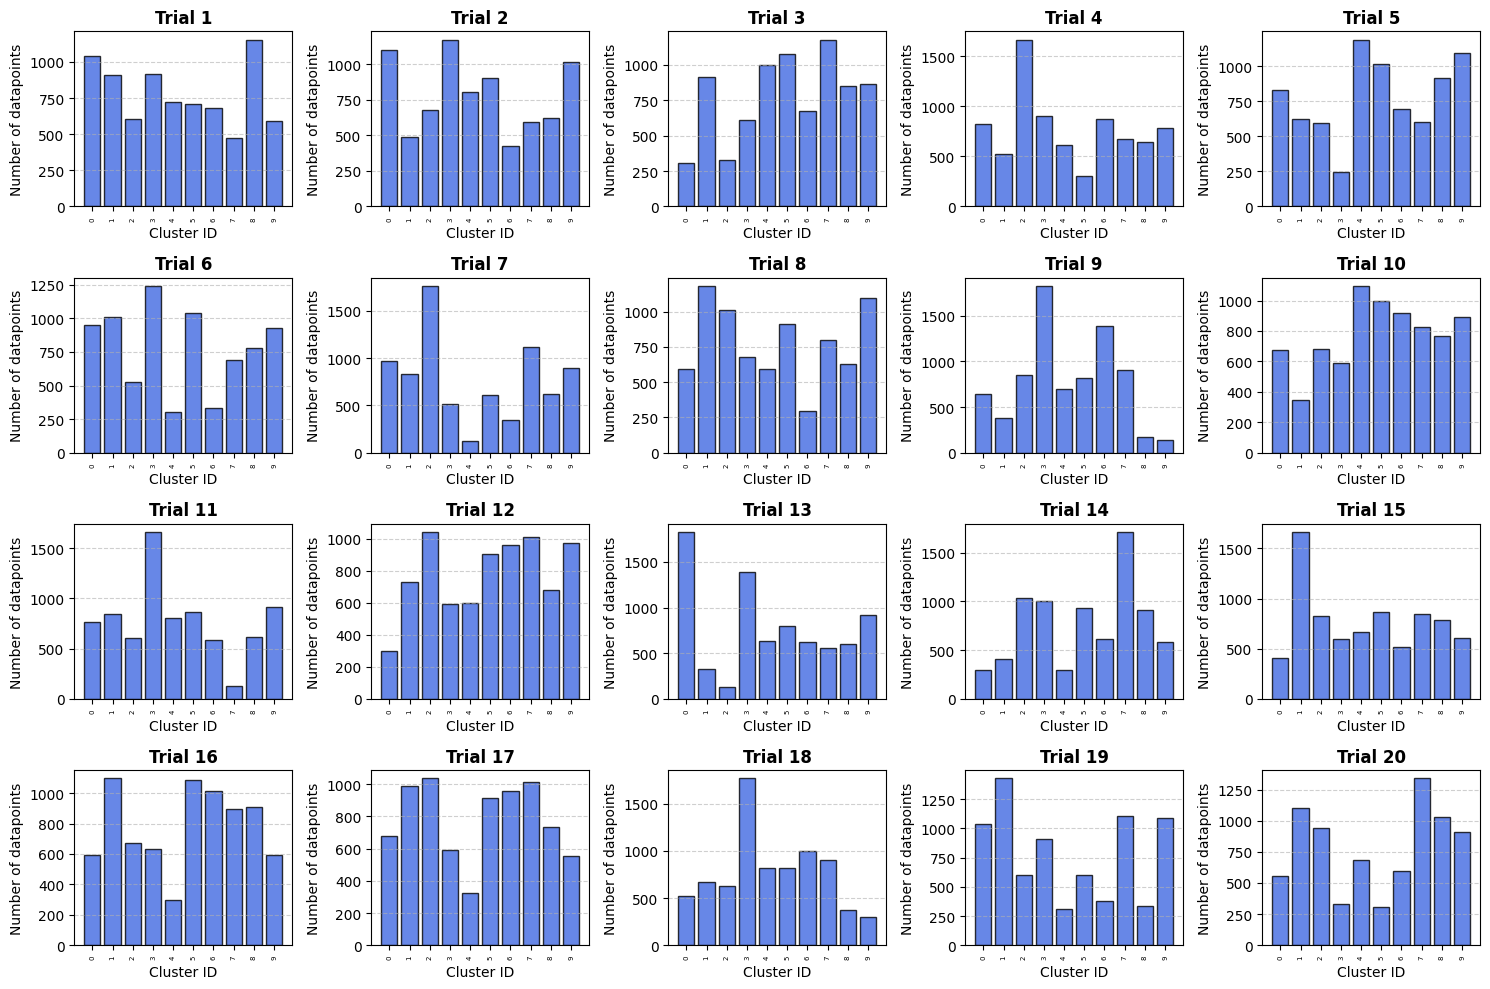


k = 26
--------------------


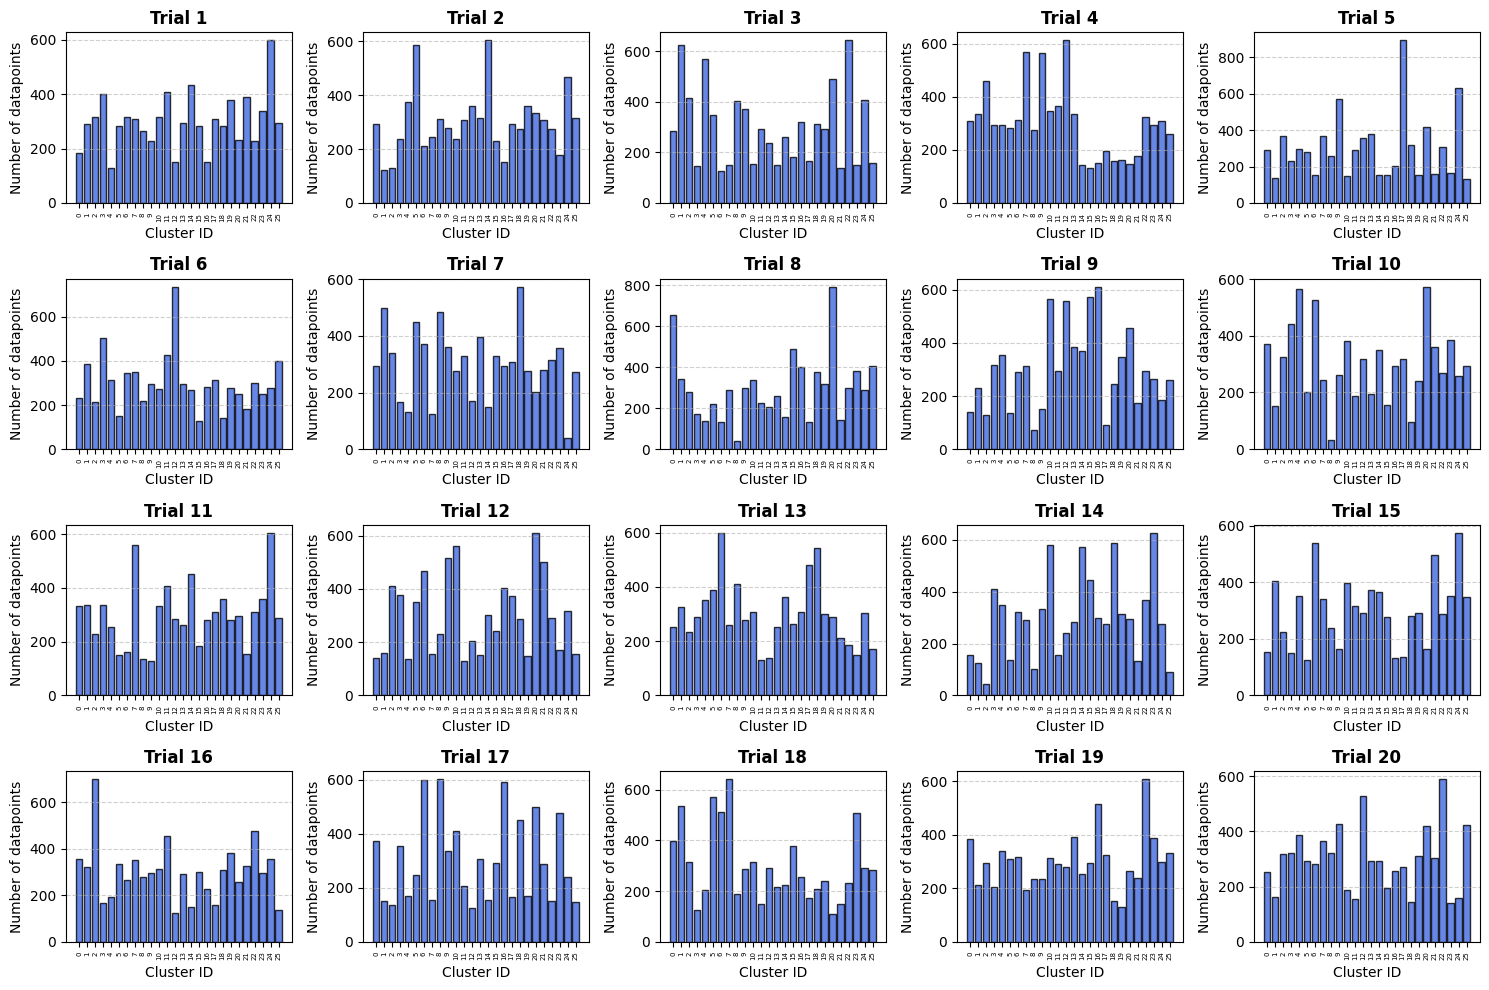


k = 50
--------------------


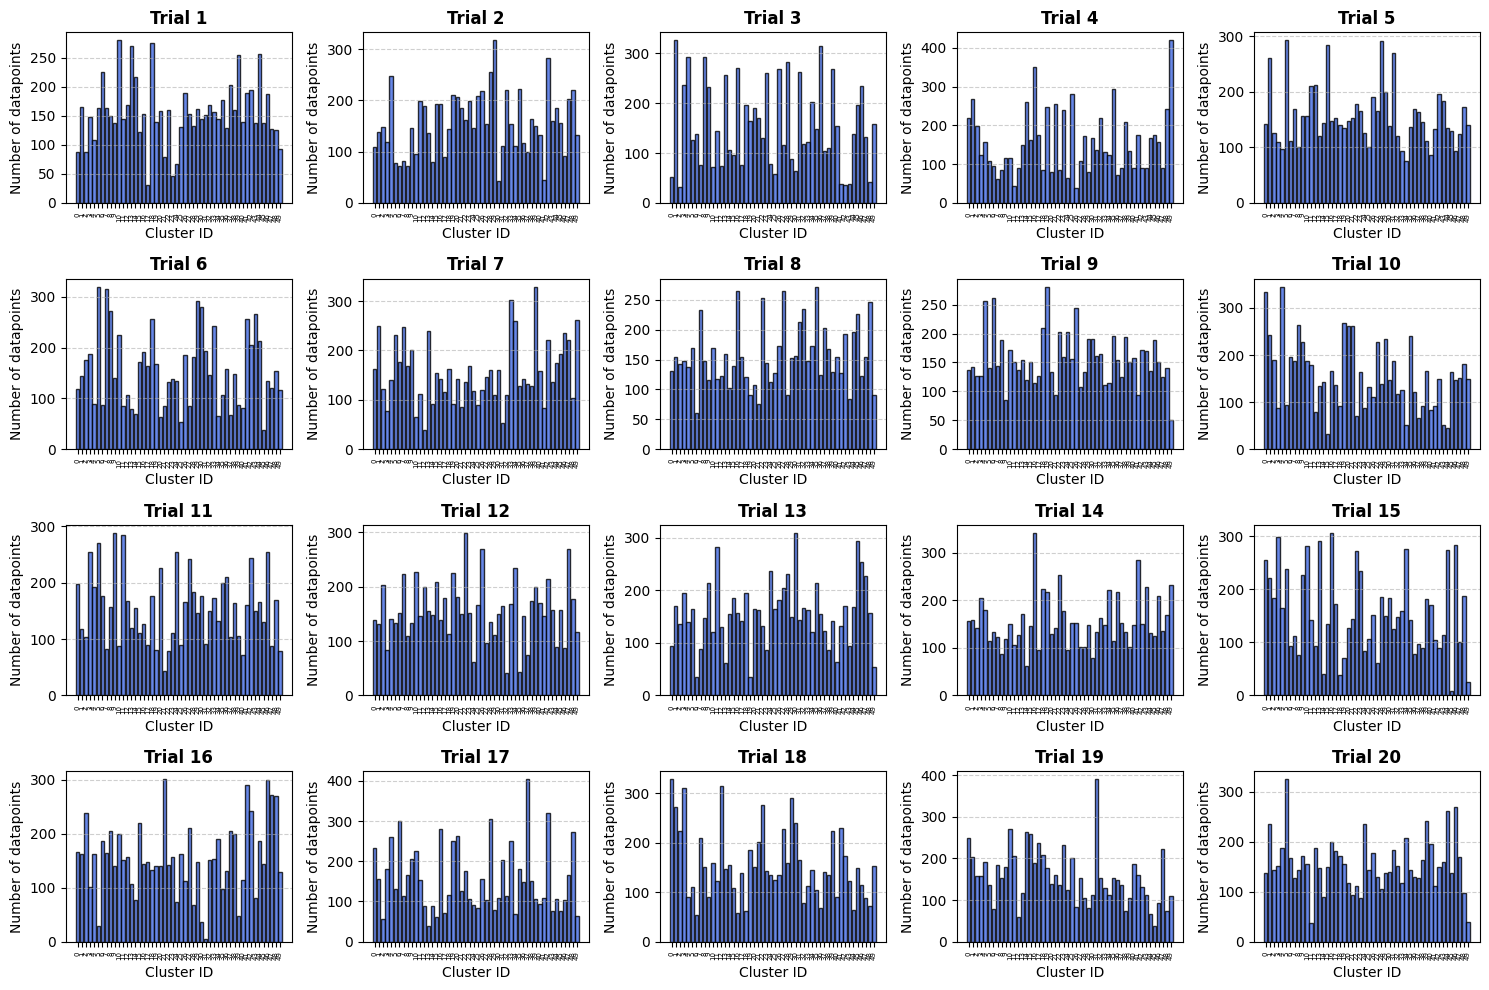

In [34]:
for i, k in enumerate(real_k_values):
    print(f'k = {k}')
    print('-'*20)
    show_distributions(real_stats[k]['kmeanspp']['bincounts'], f'cl_sz_distr_real_kmpp_k{k}')
    if i < len(real_k_values) - 1: print()

### Improvement analysis

In [35]:
for i, (k, v) in enumerate(real_stats.items()):
    print(f'k = {k}')
    print('-'*20)
    print(f"Average execution time improvement: {100*(1- np.mean(real_stats[k]['kmeanspp']['times']) / np.mean(real_stats[k]['kmeans']['times']))}%")
    print(f"Average inertia improvement: {100*(1-np.mean(real_stats[k]['kmeanspp']['inertias']) / np.mean(real_stats[k]['kmeans']['inertias']))}%")
    print(f"Inertia standard deviation improvement: {100*(1-np.std(real_stats[k]['kmeanspp']['inertias']) / np.std(real_stats[k]['kmeans']['inertias']))}%")
    print(f"Minimum inertia improvement: {100*(1-np.min(real_stats[k]['kmeanspp']['inertias']) / np.min(real_stats[k]['kmeans']['inertias']))}%")
    if i < len(real_stats.items()) - 1: print()

k = 10
--------------------
Average execution time improvement: 8.77330558834808%
Average inertia improvement: 0.5210421668831455%
Inertia standard deviation improvement: 42.820582911331364%
Minimum inertia improvement: -0.2653971759202012%

k = 26
--------------------
Average execution time improvement: 8.579715579645752%
Average inertia improvement: 0.41256489746740455%
Inertia standard deviation improvement: 31.352782393737776%
Minimum inertia improvement: 0.022755799896045925%

k = 50
--------------------
Average execution time improvement: -10.401582994578318%
Average inertia improvement: 0.09345046195322615%
Inertia standard deviation improvement: 4.991199100092947%
Minimum inertia improvement: 0.1595666009527763%


### Stability analysis

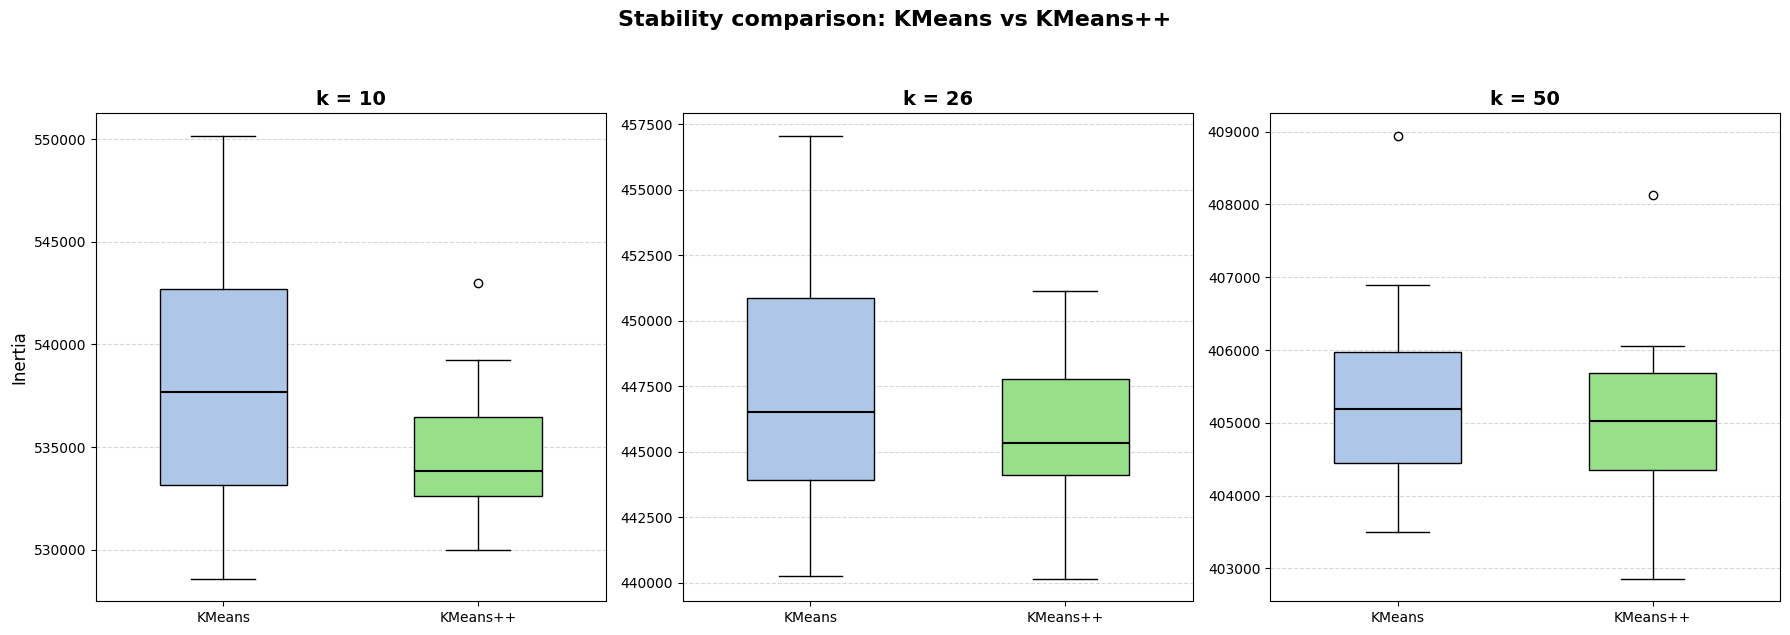

In [36]:
show_stability_graphs(real_stats, 'stab_real')